# Retail Demand Forecasting — Exploratory Analysis

## Objective

The aim of this analysis is to understand how product demand changes over time and identify the most suitable level of detail for forecasting.

I will explore:

- overall demand trends
- weekly and monthly seasonality
- which products contribute most to demand
- how stable or volatile product demand is
- how demand varies by country
- which products are suitable for forecasting
- whether daily or weekly forecasting is more appropriate

## Initial Dataset Check

I first checked the size and structure of the cleaned dataset to confirm that the expected fields and data types were available before starting the exploratory analysis.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_CLEAN = Path("../data/cleaned")
FILE_PATH = DATA_CLEAN / "retail_transactions_clean.csv"

retail = pd.read_csv(
    FILE_PATH,
    parse_dates=["invoice_date"]
)

retail.head()

,invoice,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,gross_order_value
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [3]:
print("Rows and columns:", retail.shape)

print("\nData types:")
print(retail.dtypes)

Rows and columns: (1004262, 9)

Data types:
invoice                       int64
stock_code                      str
description                     str
quantity                      int64
invoice_date         datetime64[us]
unit_price                  float64
customer_id                 float64
country                         str
gross_order_value           float64
dtype: object


## Overall Demand Trend

I first looked at total units ordered over time to understand the overall demand pattern and identify any obvious seasonality, growth, decline or unusual spikes.

In [4]:
daily_demand = (
    retail
    .groupby(retail["invoice_date"].dt.date)["quantity"]
    .sum()
    .reset_index()
)

daily_demand.columns = ["date", "quantity"]
daily_demand.head()

,date,quantity
0,2009-12-01,25809
1,2009-12-02,31802
2,2009-12-03,47864
3,2009-12-04,21183
4,2009-12-05,5119


## Overall Demand Trend

I first looked at total units ordered over time to understand the overall demand pattern and identify any obvious seasonality, growth, decline or unusual spikes.

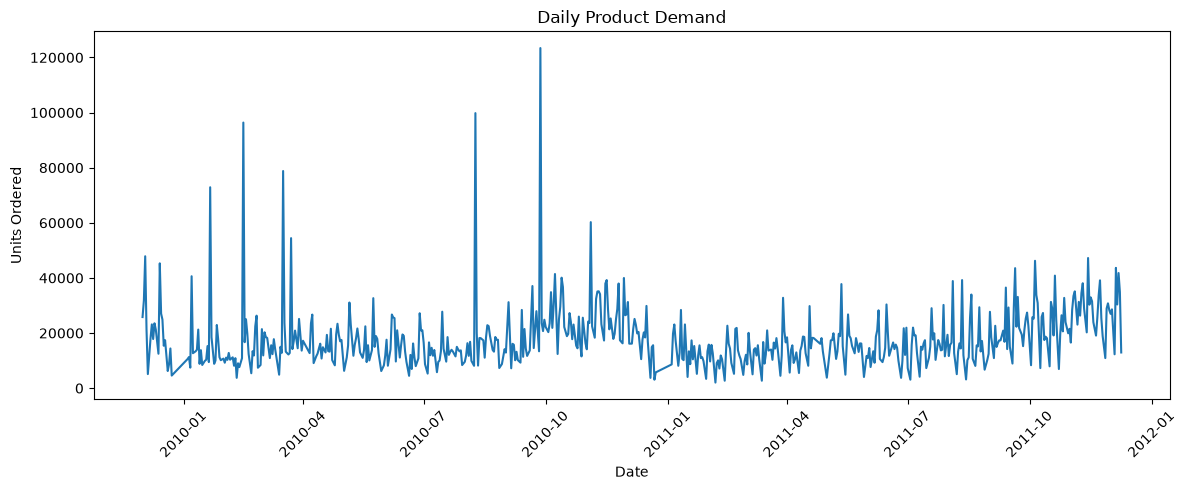

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_demand["date"],
    daily_demand["quantity"]
)

plt.title("Daily Product Demand")
plt.xlabel("Date")
plt.ylabel("Units Ordered")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Initial Observation

Daily demand is highly variable, with several sharp spikes that make the underlying pattern difficult to interpret.

There also appears to be stronger demand toward the later months of each year, suggesting possible seasonality.

Because the daily series is noisy, I will compare it with weekly aggregated demand before deciding which time grain is more suitable for forecasting.

In [6]:
weekly_demand = (
    retail
    .set_index("invoice_date")
    .resample("W")["quantity"]
    .sum()
    .reset_index()
)

weekly_demand.head()

,invoice_date,quantity
0,2009-12-06,143285
1,2009-12-13,116233
2,2009-12-20,136284
3,2009-12-27,27756
4,2010-01-03,0


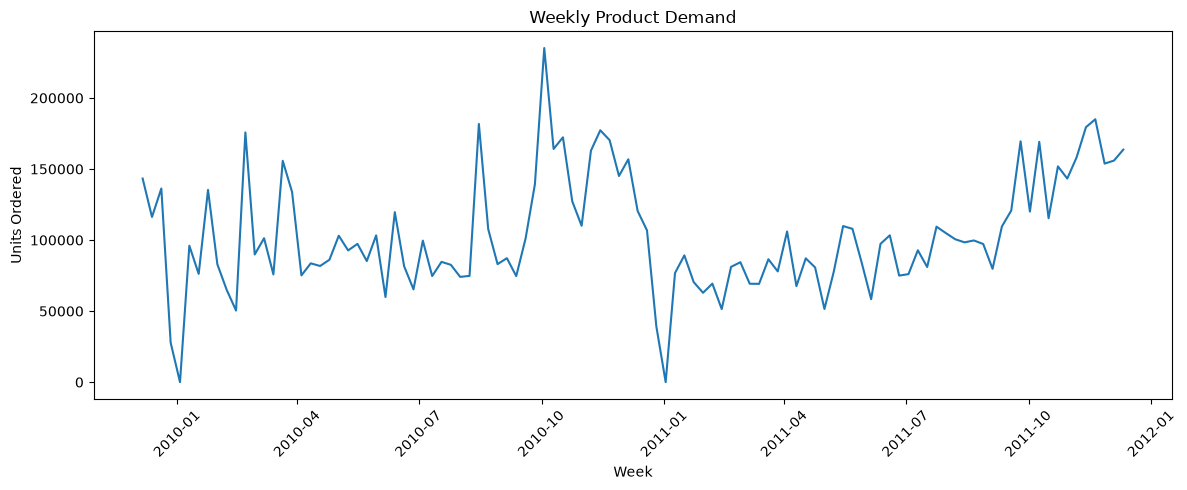

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    weekly_demand["invoice_date"],
    weekly_demand["quantity"]
)

plt.title("Weekly Product Demand")
plt.xlabel("Week")
plt.ylabel("Units Ordered")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Weekly Demand Observation

The weekly aggregation reduces much of the day-to-day noise and makes the underlying demand pattern easier to interpret.

Demand appears to strengthen toward the later months of each year, with noticeable peaks around the autumn and pre-Christmas period. There is also a sharp reduction around the end of December and beginning of January.

Based on this comparison, weekly demand is likely to be more suitable than daily demand for the forecasting stage.

## Weekly Trading Coverage

The weekly chart contains a few very low-demand periods around Christmas and New Year. Before treating these as genuine demand drops, I checked how many active transaction days were present in each week.

In [8]:
weekly_activity = (
    retail
    .assign(invoice_day=retail["invoice_date"].dt.date)
    .set_index("invoice_date")
    .resample("W")
    .agg(
        weekly_quantity=("quantity", "sum"),
        active_days=("invoice_day", "nunique")
    )
    .reset_index()
)

weekly_activity.head()

,invoice_date,weekly_quantity,active_days
0,2009-12-06,143285,6
1,2009-12-13,116233,6
2,2009-12-20,136284,6
3,2009-12-27,27756,3
4,2010-01-03,0,0


In [9]:
weekly_activity.nsmallest(
    10,
    "weekly_quantity"
)

,invoice_date,weekly_quantity,active_days
4,2010-01-03,0,0
56,2011-01-02,0,0
3,2009-12-27,27756,3
55,2010-12-26,39310,4
10,2010-02-14,50371,6
62,2011-02-13,51433,6
73,2011-05-01,51481,4
78,2011-06-05,58332,5
26,2010-06-06,59899,5
60,2011-01-30,62885,6


### Weekly Trading Coverage Observation

The lowest-demand weeks coincide with reduced or zero trading activity around Christmas and New Year.

Two weeks contain no active transaction days at all, while other low-demand weeks contain only three or four trading days.

This suggests that some apparent demand drops are caused by business closure or partial trading weeks rather than a genuine fall in customer demand. Trading coverage will therefore need to be considered when preparing the forecasting dataset.

In [10]:
weekly_activity["complete_week"] = (
    weekly_activity["active_days"] >= 5
)

weekly_activity["complete_week"].value_counts()

complete_week
True     99
False     7
Name: count, dtype: int64

### Complete Week Check

Most weeks contain at least five active trading days, with only seven weeks classified as partial or closed.

This means weekly aggregation remains suitable for forecasting, but the small number of incomplete weeks should be handled carefully during model preparation.

In [11]:
monthly_demand = (
    retail
    .set_index("invoice_date")
    .resample("ME")["quantity"]
    .sum()
    .reset_index()
)

monthly_demand.head()

,invoice_date,quantity
0,2009-12-31,423558
1,2010-01-31,390404
2,2010-02-28,380896
3,2010-03-31,524561
4,2010-04-30,365435


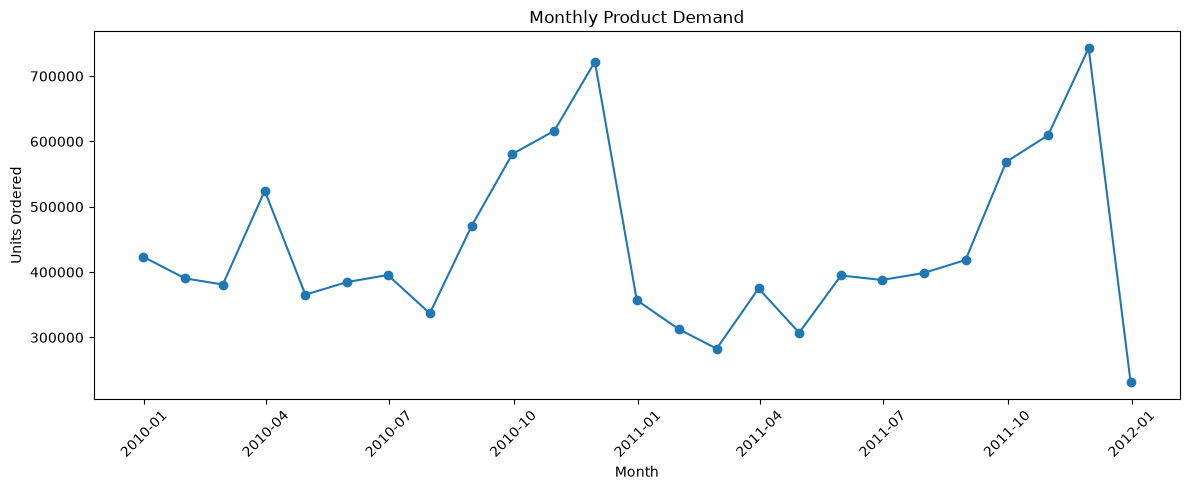

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_demand["invoice_date"],
    monthly_demand["quantity"],
    marker="o"
)

plt.title("Monthly Product Demand")
plt.xlabel("Month")
plt.ylabel("Units Ordered")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Monthly Demand Observation

Monthly demand shows a clearer seasonal pattern than the daily and weekly views.

Demand generally increases from late summer into autumn, with October and November showing the strongest volumes in both years. This suggests that the business experiences a recurring increase in demand in the run-up to Christmas.

The final December 2011 value is much lower because the dataset only contains transactions up to 9 December 2011. It should therefore not be interpreted as a full-month decline in demand.

In [14]:
retail["year"] = retail["invoice_date"].dt.year
retail["month"] = retail["invoice_date"].dt.month

monthly_by_year = (
    retail
    .groupby(["year", "month"])["quantity"]
    .sum()
    .reset_index()
)

monthly_by_year.head()

,year,month,quantity
0,2009,12,423558
1,2010,1,390404
2,2010,2,380896
3,2010,3,524561
4,2010,4,365435


In [16]:
monthly_compare = monthly_by_year[
    ~(
        (monthly_by_year["year"] == 2011)
        & (monthly_by_year["month"] == 12)
    )
].copy()

## Seasonal Comparison by Year

I compared monthly demand across 2010 and 2011 to check whether the same seasonal pattern appears in both years.

December 2011 is excluded because the source data only runs to 9 December, so it is not a complete month.

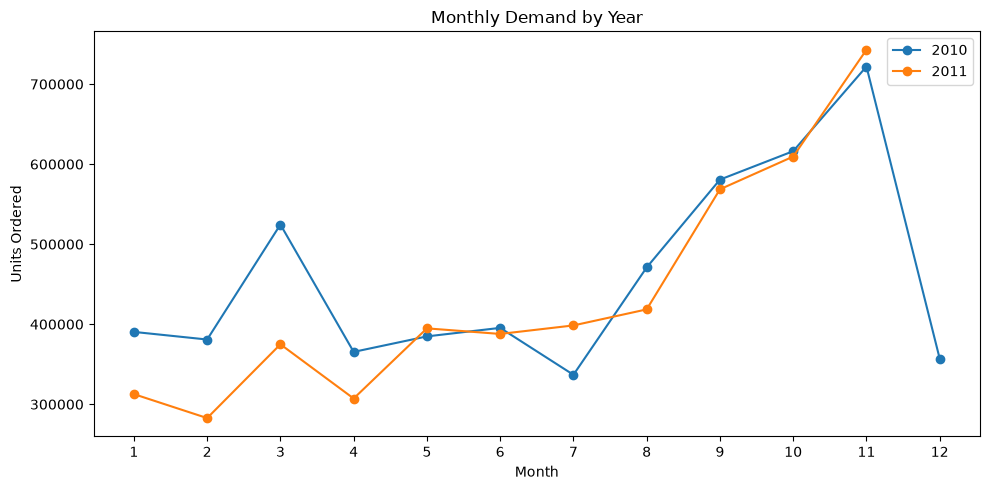

In [17]:
plt.figure(figsize=(10, 5))

for year in [2010, 2011]:
    year_data = monthly_compare[
        monthly_compare["year"] == year
    ]

    plt.plot(
        year_data["month"],
        year_data["quantity"],
        marker="o",
        label=str(year)
    )

plt.title("Monthly Demand by Year")
plt.xlabel("Month")
plt.ylabel("Units Ordered")
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()

plt.show()

### Seasonal Comparison Observation

The year-by-year comparison shows a similar seasonal pattern in both 2010 and 2011.

Demand is generally lower through the earlier part of the year before increasing from late summer into autumn. September, October and especially November show consistently stronger demand across both years.

Although some individual months differ, such as the larger March spike in 2010, the repeated increase toward the end of the year provides evidence of recurring seasonality that should be considered during forecasting.

## Product Demand Concentration

I next looked at demand by product to understand whether sales are spread evenly across the product range or concentrated among a smaller number of high-volume items.

This will help determine whether the forecasting stage should focus on all products or a selected group of higher-demand SKUs.

In [21]:
product_demand = (
    retail
    .groupby("stock_code")["quantity"]
    .sum()
    .reset_index()
    .sort_values(
        "quantity",
        ascending=False
    )
)

product_descriptions = (
    retail
    .dropna(subset=["description"])
    .groupby("stock_code")["description"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

product_demand = product_demand.merge(
    product_descriptions,
    on="stock_code",
    how="left"
)

product_demand = product_demand[
    ["stock_code", "description", "quantity"]
]

product_demand.head(10)

,stock_code,description,quantity
0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,106043
1,85099B,JUMBO BAG RED RETROSPOT,95991
2,21212,PACK OF 72 RETROSPOT CAKE CASES,94740
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,93769
4,22197,SMALL POPCORN HOLDER,88299
5,84879,ASSORTED COLOUR BIRD ORNAMENT,79869
6,17003,BROCADE RING PURSE,70333
7,21977,PACK OF 60 PINK PAISLEY CAKE CASES,56013
8,84991,60 TEATIME FAIRY CAKE CASES,53980
9,15036,ASSORTED COLOURS SILK FAN,44188


### Product Key Decision

Some StockCodes appear with slightly different product descriptions over time.

Because `StockCode` is the stable product identifier, product demand is aggregated by StockCode rather than description. The most common description is then added back for readability.

### Demand Concentration

I calculated each product's share of total unit demand to understand how concentrated demand is across the product range.

This helps identify whether forecasting should focus on a smaller group of high-impact products rather than treating every SKU equally.

In [23]:
total_units = product_demand["quantity"].sum()

product_demand["demand_share_pct"] = (
    product_demand["quantity"] / total_units * 100
)

product_demand["cumulative_share_pct"] = (
    product_demand["demand_share_pct"].cumsum()
)

product_demand.head(10)

for n in [10, 25, 50, 100]:
    share = product_demand.head(n)["demand_share_pct"].sum()
    print(f"Top {n} products: {share:.2f}% of total demand")

Top 10 products: 7.13% of total demand
Top 25 products: 12.31% of total demand
Top 50 products: 18.87% of total demand
Top 100 products: 27.99% of total demand


### Demand Concentration Observation

Demand is spread across a broad product range rather than being dominated by a small number of SKUs.

The top 100 products account for around 28% of total unit demand, suggesting that forecasting every product individually would create a large and potentially noisy modelling problem.

I will therefore identify a smaller group of products with sufficient demand volume and trading history for the forecasting stage.

## Product Demand Regularity

I next looked at how consistently products generate demand across weeks.

This helps distinguish between products with steady, repeatable demand and products that sell in occasional large spikes.

In [25]:
weekly_product_demand = (
    retail
    .set_index("invoice_date")
    .groupby("stock_code")["quantity"]
    .resample("W")
    .sum()
    .reset_index()
)

product_regularity = (
    weekly_product_demand
    .groupby("stock_code")
    .agg(
        total_units=("quantity", "sum"),
        average_weekly_demand=("quantity", "mean"),
        std_weekly_demand=("quantity", "std"),
        active_weeks=("quantity", lambda x: (x > 0).sum()),
        total_weeks=("quantity", "size")
    )
    .reset_index()
)

product_regularity["active_week_pct"] = (
    product_regularity["active_weeks"]
    / product_regularity["total_weeks"]
    * 100
)

product_regularity.head()

,stock_code,total_units,average_weekly_demand,std_weekly_demand,active_weeks,total_weeks,active_week_pct
0,10002,7649,104.780822,148.830090,70,73,95.890411
1,10002R,4,0.444444,0.726483,3,9,33.333333
2,10080,315,3.028846,8.828965,20,104,19.230769
3,10109,4,4.000000,NaN,1,1,100.000000
4,10120,664,6.323810,14.573748,42,105,40.000000


### Product Regularity Observation

Products vary considerably in how consistently they generate demand.

Some products are active across most weeks in their available history, while others sell only intermittently. A high active-week percentage on its own can also be misleading for products with very short trading histories.

For forecasting, I will therefore consider both demand regularity and the length of available sales history when selecting suitable products.

## Initial Forecast Candidate Screen

To avoid modelling products with very short or highly intermittent sales histories, I applied an initial screen based on:

- at least 52 weeks of available history
- demand in at least 70% of available weeks

These thresholds are used as a first filter rather than a final modelling decision.

In [26]:
forecast_candidates = product_regularity[
    (product_regularity["total_weeks"] >= 52)
    & (product_regularity["active_week_pct"] >= 70)
].copy()

print("Forecast candidates:", len(forecast_candidates))

forecast_candidates.sort_values(
    "total_units",
    ascending=False
).head(10)

Forecast candidates: 1342


,stock_code,total_units,average_weekly_demand,std_weekly_demand,active_weeks,total_weeks,active_week_pct
3538,84077,106043,1000.405660,972.816997,103,106,97.169811
4268,85099B,95991,905.575472,468.223470,104,106,98.113208
613,21212,94740,893.773585,495.862064,104,106,98.113208
4296,85123A,93769,884.613208,559.884760,104,106,98.113208
1430,22197,88299,833.009434,962.221344,104,106,98.113208
3987,84879,79869,753.481132,700.721047,104,106,98.113208
114,17003,70333,663.518868,1391.041722,98,106,92.452830
1243,21977,56013,528.424528,392.861322,104,106,98.113208
4123,84991,53980,509.245283,338.190136,104,106,98.113208
17,15036,44188,416.867925,521.042966,102,106,96.226415


## Demand Volatility

Regular demand does not necessarily mean stable demand. Some products sell in most weeks but have large variations in the number of units ordered.

I therefore compared each product's weekly standard deviation with its average weekly demand to identify products with more predictable demand patterns.

In [27]:
forecast_candidates["coefficient_of_variation"] = (
    forecast_candidates["std_weekly_demand"]
    / forecast_candidates["average_weekly_demand"]
)

forecast_candidates.sort_values(
    "total_units",
    ascending=False
).head(10)

,stock_code,total_units,average_weekly_demand,std_weekly_demand,active_weeks,total_weeks,active_week_pct,coefficient_of_variation
3538,84077,106043,1000.405660,972.816997,103,106,97.169811,0.972423
4268,85099B,95991,905.575472,468.223470,104,106,98.113208,0.517045
613,21212,94740,893.773585,495.862064,104,106,98.113208,0.554796
4296,85123A,93769,884.613208,559.884760,104,106,98.113208,0.632915
1430,22197,88299,833.009434,962.221344,104,106,98.113208,1.155115
3987,84879,79869,753.481132,700.721047,104,106,98.113208,0.929978
114,17003,70333,663.518868,1391.041722,98,106,92.452830,2.096461
1243,21977,56013,528.424528,392.861322,104,106,98.113208,0.743458
4123,84991,53980,509.245283,338.190136,104,106,98.113208,0.664101
17,15036,44188,416.867925,521.042966,102,106,96.226415,1.249899


### Demand Volatility Observation

The coefficient of variation shows that products with similar demand frequency can still behave very differently.

Some high-volume products have relatively stable weekly demand, while others show substantial variation despite being active in most weeks.

This suggests that the most suitable forecasting candidates should combine:

- sufficient sales history
- frequent weekly demand
- meaningful demand volume
- moderate rather than extreme volatility

In [28]:
forecast_shortlist = forecast_candidates[
    forecast_candidates["coefficient_of_variation"] <= 1.0
].copy()

forecast_shortlist = forecast_shortlist.sort_values(
    "total_units",
    ascending=False
)

print("Shortlisted products:", len(forecast_shortlist))

forecast_shortlist.head(10)

Shortlisted products: 353


,stock_code,total_units,average_weekly_demand,std_weekly_demand,active_weeks,total_weeks,active_week_pct,coefficient_of_variation
3538,84077,106043,1000.405660,972.816997,103,106,97.169811,0.972423
4268,85099B,95991,905.575472,468.223470,104,106,98.113208,0.517045
613,21212,94740,893.773585,495.862064,104,106,98.113208,0.554796
4296,85123A,93769,884.613208,559.884760,104,106,98.113208,0.632915
3987,84879,79869,753.481132,700.721047,104,106,98.113208,0.929978
1243,21977,56013,528.424528,392.861322,104,106,98.113208,0.743458
4123,84991,53980,509.245283,338.190136,104,106,98.113208,0.664101
1699,22492,43498,517.833333,372.585943,83,84,98.809524,0.719509
3862,84755,40263,379.839623,338.433144,104,106,98.113208,0.890990
614,21213,40215,379.386792,301.325345,104,106,98.113208,0.794243


### Forecast Shortlist Observation

The shortlist contains products with long sales histories, frequent weekly demand and moderate levels of volatility.

This creates a more suitable modelling population than selecting products based on total volume alone. Highly intermittent or extremely volatile products have been excluded from the initial forecasting scope.

In [30]:
selected_products = (
    forecast_shortlist
    .head(5)
    .copy()
)

selected_products = selected_products.merge(
    product_descriptions,
    on="stock_code",
    how="left"
)

selected_products[
    [
        "stock_code",
        "description",
        "total_units",
        "average_weekly_demand",
        "active_week_pct",
        "coefficient_of_variation"
    ]
]

,stock_code,description,total_units,average_weekly_demand,active_week_pct,coefficient_of_variation
0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,106043,1000.405660,97.169811,0.972423
1,85099B,JUMBO BAG RED RETROSPOT,95991,905.575472,98.113208,0.517045
2,21212,PACK OF 72 RETROSPOT CAKE CASES,94740,893.773585,98.113208,0.554796
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,93769,884.613208,98.113208,0.632915
4,84879,ASSORTED COLOUR BIRD ORNAMENT,79869,753.481132,98.113208,0.929978


## Selected Products for Forecasting

I selected the five highest-volume products from the shortlist for the initial forecasting stage.

These products have:

- at least one year of available history
- demand in at least 70% of available weeks
- moderate rather than extreme weekly volatility
- high overall demand volume

This keeps the modelling scope manageable while focusing on products with suitable forecasting characteristics.

## Selected Product Demand Patterns

Before moving into forecasting, I reviewed the weekly demand history of the selected products to check for unusual spikes, structural changes or inconsistent behaviour that could affect model performance.

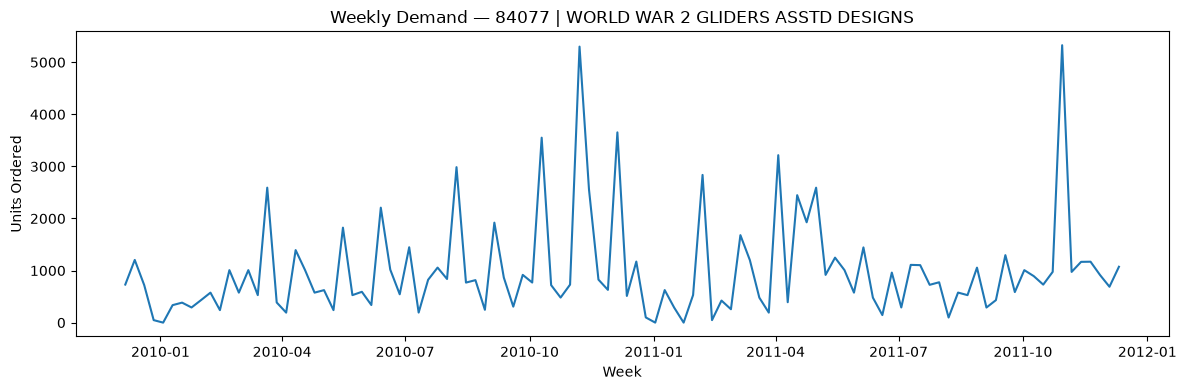

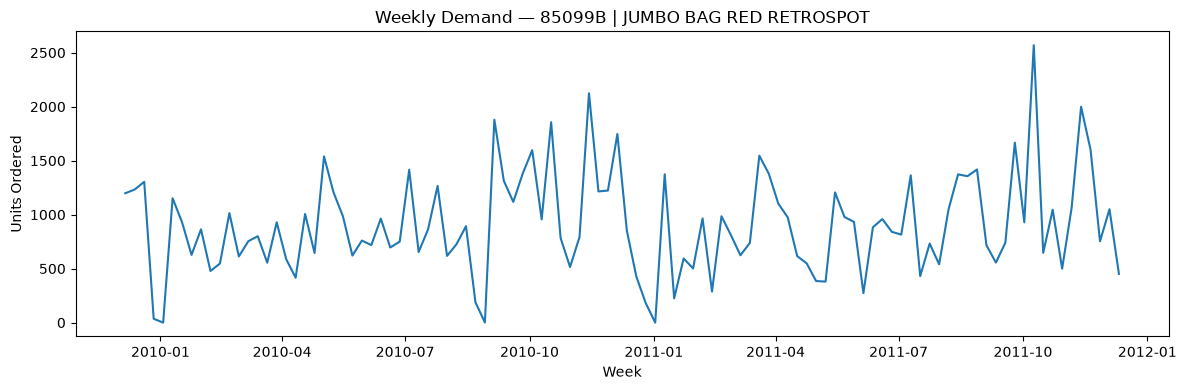

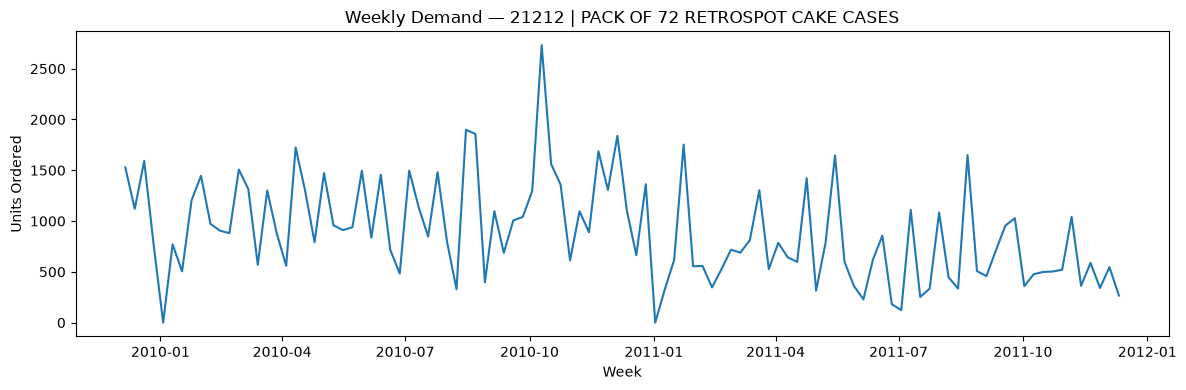

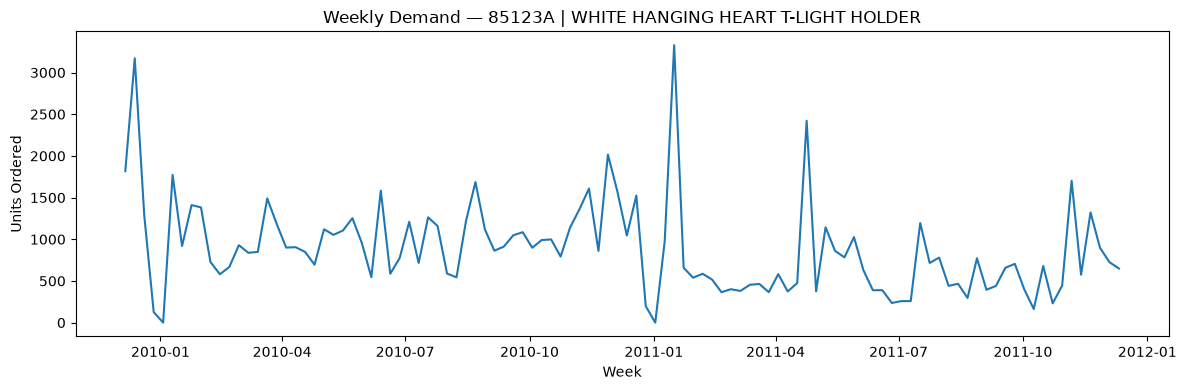

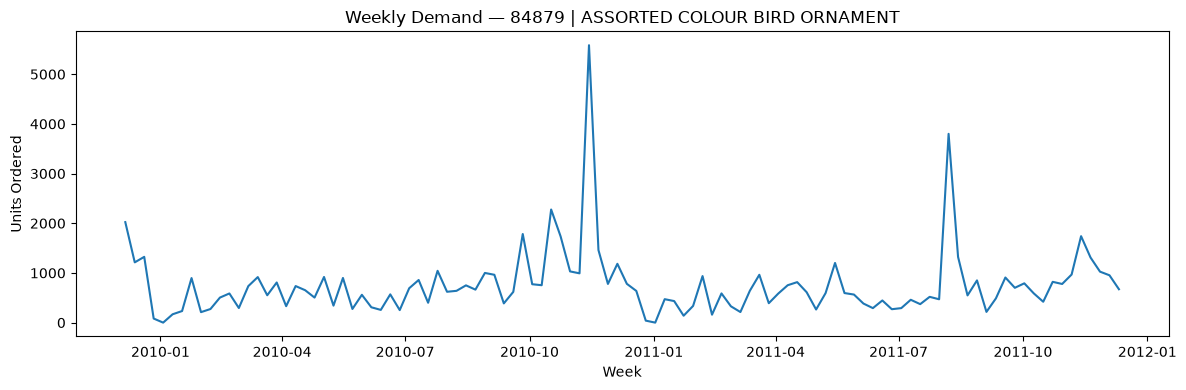

In [31]:
selected_stock_codes = selected_products["stock_code"].tolist()

selected_weekly_demand = weekly_product_demand[
    weekly_product_demand["stock_code"].isin(selected_stock_codes)
].copy()

for stock_code in selected_stock_codes:
    product_data = selected_weekly_demand[
        selected_weekly_demand["stock_code"] == stock_code
    ]

    description = selected_products.loc[
        selected_products["stock_code"] == stock_code,
        "description"
    ].iloc[0]

    plt.figure(figsize=(12, 4))

    plt.plot(
        product_data["invoice_date"],
        product_data["quantity"]
    )

    plt.title(f"Weekly Demand — {stock_code} | {description}")
    plt.xlabel("Week")
    plt.ylabel("Units Ordered")

    plt.tight_layout()
    plt.show()

### Selected Product Demand Observation

The selected products all have frequent weekly demand, but their demand patterns are not identical.

Some products, such as `85099B`, show relatively consistent weekly demand, while others contain larger spikes or changes in demand level over time. Products such as `21212` and `85123A` also appear to have lower average demand during parts of 2011 compared with 2010.

I will retain all five products for forecasting because they provide a useful mix of stable, volatile and changing demand patterns. This will allow model performance to be compared across different types of product behaviour.

## Country Contribution

I also looked at where demand comes from geographically to understand whether the dataset is dominated by one market or spread across several countries.

This helps provide business context for the forecasting analysis and shows whether the selected products are mainly driven by UK demand or broader international demand.

In [32]:
country_demand = (
    retail
    .groupby("country")["quantity"]
    .sum()
    .reset_index()
    .sort_values(
        "quantity",
        ascending=False
    )
)

country_demand["demand_share_pct"] = (
    country_demand["quantity"]
    / country_demand["quantity"].sum()
    * 100
)

country_demand.head(10)

,country,quantity,demand_share_pct
40,United Kingdom,8968078,81.687942
26,Netherlands,383864,3.496520
11,EIRE,331919,3.023366
14,France,270888,2.467450
10,Denmark,237471,2.163063
15,Germany,225117,2.050533
0,Australia,103564,0.943338
35,Sweden,88588,0.806926
36,Switzerland,52563,0.478783
34,Spain,50303,0.458197


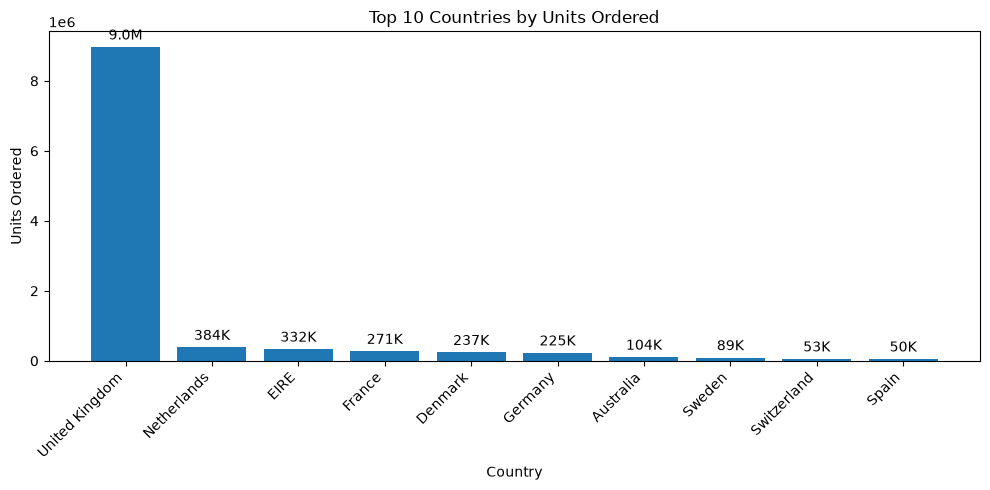

In [34]:
top_countries = country_demand.head(10)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    top_countries["country"],
    top_countries["quantity"]
)

plt.title("Top 10 Countries by Units Ordered")
plt.xlabel("Country")
plt.ylabel("Units Ordered")

plt.xticks(rotation=45, ha="right")

labels = [
    f"{value / 1_000_000:.1f}M"
    if value >= 1_000_000
    else f"{value / 1_000:.0f}K"
    for value in top_countries["quantity"]
]

plt.bar_label(
    bars,
    labels=labels,
    padding=3
)

plt.tight_layout()
plt.show()

### Country Contribution Observation

Demand is heavily concentrated in the United Kingdom, with international markets contributing a much smaller share of total units ordered.

This means the forecasting analysis will primarily reflect UK demand behaviour, although international transactions remain part of the overall dataset.

The strong UK concentration also helps explain why seasonal patterns around the Christmas trading period are particularly important in the demand series.

## Forecasting Dataset Preparation

Based on the exploratory analysis, I will use weekly demand for the five selected products.

Weekly aggregation reduces daily noise while retaining the main demand patterns. I will also keep a flag for incomplete trading weeks so these periods can be handled appropriately during modelling rather than being mistaken for normal low demand.

In [35]:
forecast_data = selected_weekly_demand.merge(
    selected_products[
        ["stock_code", "description"]
    ],
    on="stock_code",
    how="left"
)

forecast_data = forecast_data.merge(
    weekly_activity[
        ["invoice_date", "active_days", "complete_week"]
    ],
    on="invoice_date",
    how="left"
)

forecast_data = forecast_data.rename(
    columns={"quantity": "weekly_demand"}
)

forecast_data = forecast_data[
    [
        "invoice_date",
        "stock_code",
        "description",
        "weekly_demand",
        "active_days",
        "complete_week"
    ]
].sort_values(
    ["stock_code", "invoice_date"]
)

forecast_data.head()

,invoice_date,stock_code,description,weekly_demand,active_days,complete_week
0,2009-12-06,21212,PACK OF 72 RETROSPOT CAKE CASES,1528,6,True
1,2009-12-13,21212,PACK OF 72 RETROSPOT CAKE CASES,1121,6,True
2,2009-12-20,21212,PACK OF 72 RETROSPOT CAKE CASES,1591,6,True
3,2009-12-27,21212,PACK OF 72 RETROSPOT CAKE CASES,764,3,False
4,2010-01-03,21212,PACK OF 72 RETROSPOT CAKE CASES,0,0,False


In [36]:
print("Rows:", len(forecast_data))
print("Products:", forecast_data["stock_code"].nunique())
print("Missing values:")
print(forecast_data.isna().sum())

print(
    "\nDate range:",
    forecast_data["invoice_date"].min(),
    "to",
    forecast_data["invoice_date"].max()
)

Rows: 530
Products: 5
Missing values:
invoice_date     0
stock_code       0
description      0
weekly_demand    0
active_days      0
complete_week    0
dtype: int64

Date range: 2009-12-06 00:00:00 to 2011-12-11 00:00:00


## Exploratory Analysis Summary

The exploratory analysis identified several patterns that will shape the forecasting approach.

Key findings:

- weekly aggregation provides a clearer and more stable demand signal than daily data
- demand shows recurring seasonal strength in the later months of the year, especially September to November
- a small number of weeks are affected by partial or zero trading activity around Christmas and New Year
- product demand is spread across a broad SKU range rather than being heavily concentrated in only a few products
- suitable forecasting candidates need sufficient history, frequent weekly demand and manageable volatility
- five high-volume products were selected for modelling based on history, demand regularity and coefficient of variation
- the selected products show different demand behaviours, including stable demand, volatility and changes in demand level
- the United Kingdom accounts for the majority of overall demand

The forecasting stage will therefore use weekly demand for the five selected products while retaining trading-coverage information so incomplete weeks can be handled appropriately during modelling.

In [37]:
DATA_PROCESSED = Path("../data/processed")
OUTPUT_PATH = DATA_PROCESSED / "weekly_forecast_data.csv"

forecast_data.to_csv(
    OUTPUT_PATH,
    index=False
)

print(f"Saved to: {OUTPUT_PATH}")

Saved to: ..\data\processed\weekly_forecast_data.csv
